In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score)

#### LOAD DATASET

In [ ]:
# Load the dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#### DATA PREPARATION

In [ ]:
# Initial data inspection
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Check dataset information and datatypes
df.info()
# Check shape
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Convert TotalCharges from object to numeric datatype
# Invalid entries are converted to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Replace missing values in TotalCharges with the median value
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median()
)

# Remove customerID because it does not contribute to churn prediction
df.drop("customerID", axis=1, inplace=True)

##### Duplicate records can bias the model by overrepresenting certain customer profiles. Therefore, we checked for duplicate rows before proceeding.

#### EXPLORATORY DATA ANALYSIS

In [ ]:
# Analyze churn distribution
df["Churn"].value_counts()


,count
Churn,
No,5174
Yes,1869


In [ ]:
# Churn distribution percentage
churn_dist = (df["Churn"].value_counts(normalize=True)*100).round(2)
churn_dist.astype(str) + "%"

,proportion
Churn,
No,73.46%
Yes,26.54%


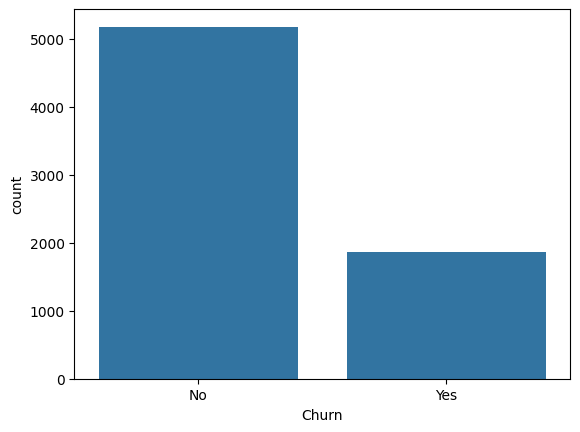

In [ ]:
sns.countplot(x="Churn",data=df)
plt.show()

##### KEY FINDINGS: The dataset is imbalanced with approximately 73% non churners and 27% churners

##### NUMERICAL FEATURES ANALYSIS

In [ ]:
# Convert churn labels into binary values
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})


In [ ]:
# Correlation matrix to understand the relationship between the numerical features and Customer Churn
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.150889
tenure,0.016567,1.000000,0.247900,0.825464,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.193356
TotalCharges,0.102652,0.825464,0.650864,1.000000,-0.199037
Churn,0.150889,-0.352229,0.193356,-0.199037,1.000000


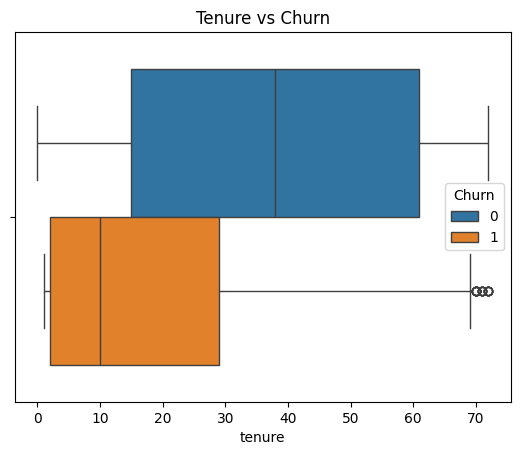

In [ ]:
sns.boxplot(x="tenure", hue="Churn", data=df)
plt.title("Tenure vs Churn")
plt.show()

#### KEY FINDINGS: Correlation analysis showed that tenure had the strongest numerical relationship with churn (-0.352), indicating that customers with longer tenure were less likely to leave the company. MonthlyCharges (0.193) and SeniorCitizen (0.151) showed weak positive relationships with churn, while TotalCharges (-0.199) exhibited a weak negative relationship. The tenure boxplot further confirmed that churned customers generally had much shorter tenure than retained customers.


In [ ]:
# Cross tabulation analysis to understand features relationship with churn
analysis = (pd.crosstab(df["tenure"], df["Churn"], normalize="index") * 100).round(2)
analysis.astype(str) + "%"

Churn,0,1
tenure,,
0,100.0%,0.0%
1,38.01%,61.99%
2,48.32%,51.68%
3,53.0%,47.0%
4,52.84%,47.16%
...,...,...
68,91.0%,9.0%
69,91.58%,8.42%
70,90.76%,9.24%


##### CATEGORICAL FEATURES ANALYSIS

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(
    include="object"
).columns

# Apply one-hot encoding to categorical columns
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)


In [ ]:
# Correlation matrix to understand the relationship between the numerical features and Customer Churn
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.150889,-0.001874,0.016479,-0.211185,0.008576,-0.008576,...,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,0.156530,-0.024135,0.171718,-0.153477
tenure,0.016567,1.000000,0.247900,0.825464,-0.352229,0.005106,0.379697,0.159712,0.008448,-0.008448,...,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.006152,0.233006,-0.208363,-0.233852
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.193356,-0.014569,0.096848,-0.113890,0.247398,-0.247398,...,-0.763557,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.352150,0.030550,0.271625,-0.377437
TotalCharges,0.102652,0.825464,0.650864,1.000000,-0.199037,-0.000002,0.318364,0.063593,0.113013,-0.113013,...,-0.374706,0.515279,-0.374706,0.519884,0.170649,0.356226,0.158055,0.182745,-0.059971,-0.294814
Churn,0.150889,-0.352229,0.193356,-0.199037,1.000000,-0.008612,-0.150448,-0.164221,0.011942,-0.011942,...,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,0.191825,-0.134302,0.301919,-0.091683
gender_Male,-0.001874,0.005106,-0.014569,-0.000002,-0.008612,1.000000,-0.001808,0.010517,-0.006488,0.006488,...,0.006026,-0.008393,0.006026,-0.010487,0.008026,-0.003695,-0.011754,0.001215,0.000752,0.013744
Partner_Yes,0.016479,0.379697,0.096848,0.318364,-0.150448,-0.001808,1.000000,0.452676,0.017706,-0.017706,...,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,-0.014877,0.082029,-0.083852,-0.095125
Dependents_Yes,-0.211185,0.159712,-0.113890,0.063593,-0.164221,0.010517,0.452676,1.000000,-0.001762,0.001762,...,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,-0.111377,0.060267,-0.150642,0.059071
PhoneService_Yes,0.008576,0.008448,0.247398,0.113013,0.011942,-0.006488,0.017706,-0.001762,1.000000,-1.000000,...,0.172209,-0.022574,0.172209,-0.032959,-0.002791,0.003519,0.016505,-0.007721,0.003062,-0.003319
MultipleLines_No phone service,-0.008576,-0.008448,-0.247398,-0.113013,-0.011942,0.006488,-0.017706,0.001762,-1.000000,1.000000,...,-0.172209,0.022574,-0.172209,0.032959,0.002791,-0.003519,-0.016505,0.007721,-0.003062,0.003319


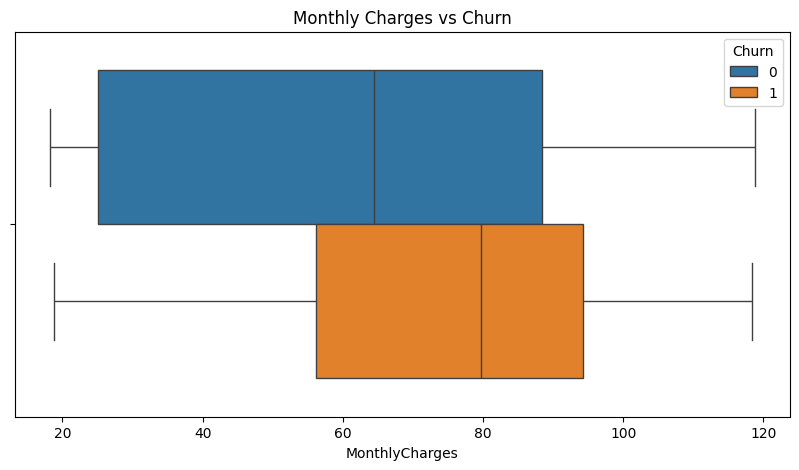

In [ ]:
# Visualize Monthly Charges against churn to understand their relationship
plt.figure(figsize=(10, 5))
sns.boxplot(x="MonthlyCharges", hue="Churn", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

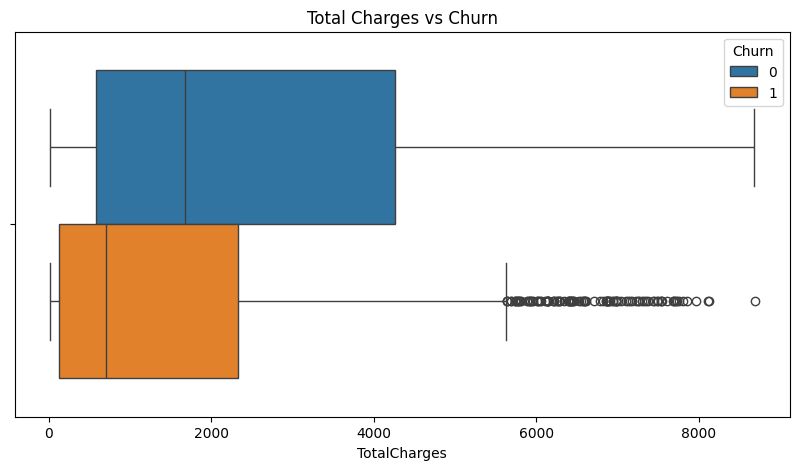

In [ ]:
# Visualize Total Charges against churn to understand their relationship
plt.figure(figsize=(10, 5))
sns.boxplot(x="TotalCharges", hue="Churn", data=df)
plt.title("Total Charges vs Churn")
plt.show()

In [ ]:
# Features correlation with Churn to understand their importance
df.corr()["Churn"]

,Churn
SeniorCitizen,0.150889
tenure,-0.352229
MonthlyCharges,0.193356
TotalCharges,-0.199037
Churn,1.000000
gender_Male,-0.008612
Partner_Yes,-0.150448
Dependents_Yes,-0.164221
PhoneService_Yes,0.011942
MultipleLines_No phone service,-0.011942


#### DEFINE FEATURES AND OUTPUT

In [ ]:
# Define features and label
X = df.drop("Churn", axis=1)
y = df["Churn"]



#### TRAIN-TEST SPLIT

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# # Export unseen testing dataset for demo
# test_df = pd.concat([X_test, y_test], axis=1)
# test_df.to_csv("test_data.csv", index=False)

#### FEATURE SCALING


In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### TRAINNING LOGISTIC REGRESSION

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# MAKING PREDICTIONS
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# Assign threshold to probabilities
y_pred_40 = (y_proba > 0.48).astype(int)

#### MODEL EVALUATION

In [ ]:
accuracy = accuracy_score(y_test, y_pred_40)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")

print(classification_report(y_test, y_pred_40))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, y_pred_40))
print("\nROC-AUC SCORE:")
print(roc_auc_score(y_test, y_proba))


Accuracy: 0.7430801987224982

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1036
           1       0.51      0.85      0.64       373

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.76      1409


Confusion Matrix:
[[731 305]
 [ 57 316]]

ROC-AUC SCORE:
0.8619031229621043


##### ROC-AUC Score evaluates the model's ability to distinguish between customers who churn and those who do not churn, regardless of the classification threshold. The Logistic Regression model achieved an ROC-AUC score of 0.862, indicating strong discriminatory power.

##### The Logistic Regression model achieved an overall accuracy of 82%, indicating that it was able to correctly classify the majority of customers. The model performed particularly well in identifying customers who remained with the company, achieving a recall score of 90% for the non-churn class. However, its performance on churn prediction was weaker, with a recall score of 60%, meaning that approximately 40% of customers who eventually churned were not identified. This difference is likely due to class imbalance within the dataset, where non-churning customers significantly outnumbered churning customers. Despite this limitation, Logistic Regression provided a strong baseline model and demonstrated that customer churn can be predicted with a reasonable degree of accuracy using the available features.

In [ ]:
features = X.columns.tolist()

In [ ]:
# Save the model, scaler and features for deployment
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(features, open("features.pkl", "wb")